In [247]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

df = pd.read_csv("Train_Data.csv")
TARGET = "Dropped_Course"
baseline_rate = df[TARGET].mean()
print(df.shape)
print(f"overall {TARGET} rate: {baseline_rate:.4f}")

(63464, 29)
overall Dropped_Course rate: 0.4144


# Numerical variables

## Prev_Course_Dropouts

count    63464.000000
mean         0.095991
std          0.448526
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         21.000000
Name: Prev_Course_Dropouts, dtype: float64


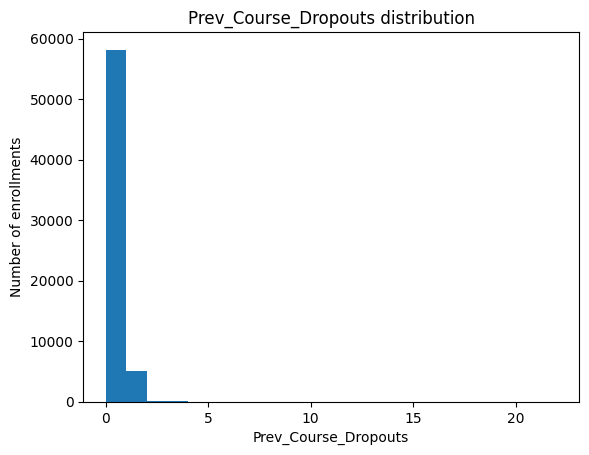

                          mean  count   pct
Prev_Course_Dropouts                       
0                     0.366046  58184  91.7
1                     0.974430   5084   8.0
2                     0.153846     65   0.1
3                     0.122449     49   0.1
4                     0.083333     12   0.0
5                     0.090909     11   0.0
6                     0.636364     11   0.0
11                    0.285714     35   0.1
13                    0.916667     12   0.0
21                    1.000000      1   0.0


In [248]:
col = "Prev_Course_Dropouts"
print(df[col].describe())

plt.hist(df[col], bins=range(0, df[col].max() + 2))
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.ylabel("Number of enrollments")
plt.show()

rate_by_val = df.groupby(col)[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

**What can you infer about `Prev_Course_Dropouts`?**

1. `0` and `1` together account for 99.7% of rows (n=58,184 and n=5,084 respectively). The remaining values (2–21) total only n=196, split across 8 sparse bins — not statistically meaningful on their own.
2. The drop rate nearly triples between these two dominant values: 36.6% at `0` vs. 97.4% at `1`. This is the effect that matters for the analysis.

**Decision:** treat `Prev_Course_Dropouts` as informative only at `0` vs. `1`; exclude rows with values ≥2 from any effect estimate involving this variable, since n=196 is too small to support a reliable per-value rate.

## Returning_Client


In [ ]:
col = "Returning_Client"
print(df[col].value_counts())

rate_by_val = df.groupby(col)[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

ax = rate_by_val["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_val["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col}")
plt.legend()
plt.show()

table = pd.crosstab(df[col], df[TARGET])

**What can you infer about `Returning_Clients`?**

1. returning clients drop out much less than new ones — 24.0% vs. 41.9%. New clients are at almost identical to baseline, so we can infer a returning client is less likely to drop.

**Decision:** keep as is.

## Prev_Course_Attended

count    63464.000000
mean         0.122967
std          1.535201
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         61.000000
Name: Prev_Course_Attended, dtype: float64
missing: 0


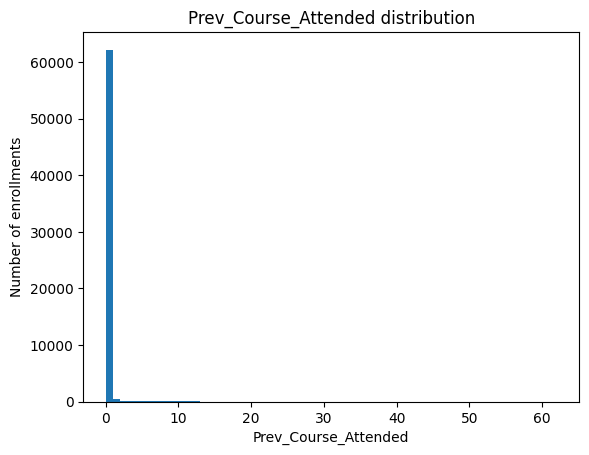

                          mean  count   pct
Prev_Course_Attended                       
0                     0.421384  62188  98.0
1                     0.068085    470   0.7
2                     0.058065    155   0.2
3                     0.056604    106   0.2
4                     0.096386     83   0.1
...                        ...    ...   ...
57                    0.000000      1   0.0
58                    0.500000      2   0.0
59                    0.000000      1   0.0
60                    0.000000      1   0.0
61                    0.000000      1   0.0

[62 rows x 3 columns]

0 vs 1+ grouped:
                          mean  count   pct
Prev_Course_Attended                       
False                 0.421384  62188  98.0
True                  0.073668   1276   2.0


In [250]:
col = "Prev_Course_Attended"
print(df[col].describe())
print("missing:", df[col].isna().sum())

plt.hist(df[col], bins=range(0, df[col].max() + 2))
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.ylabel("Number of enrollments")
plt.show()

rate_by_val = df.groupby(col)[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

has_attended = (df[col] > 0)
grouped = df.groupby(has_attended)[TARGET].agg(["mean", "count"])
grouped["pct"] = (grouped["count"] / len(df) * 100).round(1)
print("\n0 vs 1+ grouped:")
print(grouped)

**What can you infer about `Prev_Course_Attended`?**
1. Similar logic to `Prev_Course_Dropouts`: 98% of clients have a value of `0`. The remaining 2% are spread thin across 61 distinct values, many with n<5.
2. Drop rate falls from 42.1% to 7.4% once a client has attended at least one prior course — having attended before is strongly protective, making a client far less likely to drop.
**Decision**: In prev_dropouts, we can divide groups to 0, 1, other values. Here, its almost requrested to divide to 2 groups - '0' and other values.

## Registration_Days_Before

In [ ]:
col = "Registration_Days_Before"
print(df[col].describe())
print("missing:", df[col].isna().sum(), f"({df[col].isna().mean():.2%})")

plt.hist(df[col].dropna(), bins=50)
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.show()

dropped = df.loc[df[TARGET] == 1, col].dropna()
stayed = df.loc[df[TARGET] == 0, col].dropna()

plt.boxplot([stayed, dropped], labels=["stayed", "dropped"])
plt.title(f"{col} by {TARGET}")
plt.ylabel(f"{col} (days)")
plt.show()

print("stayed:", stayed.describe()[["mean", "50%"]].to_dict())
print("dropped:", dropped.describe()[["mean", "50%"]].to_dict())

# is missingness itself related to the target? -> decides imputation strategy
rate_by_missing = df.groupby(df[col].isna())[TARGET].agg(["mean", "count"])
rate_by_missing.index = ["has value", "missing"]
rate_by_missing["pct"] = (rate_by_missing["count"] / len(df) * 100).round(1)
print(rate_by_missing)

ax = rate_by_missing["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_missing["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate: {col} missing vs. present")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

**What can you infer about `Registration_Days_Before`?**

1. **Histogram — right-skewed distribution.** Mean (103) is well above the median (65), and the max reaches 629. Most clients register between 19 and 150 days ahead, with a long tail of a few registering much earlier (max = 629). This tail stretches the mean to the right, and makes it less reliable. Also, intuitivly, it seems unreasonable to register to a course almost 2 years prior to its start date. 
2. **Boxplot — stayed vs. dropped.** Clients who registered a "long" period in advance were more likely to drop, rather than ones who registered later - median 104 days (mean 148.5) for dropped vs. median 43 days (mean 70) for those who stayed. 
3. **Missing values bar chart.** 4.2% of rows (n=2,666) have no value. Their drop rate (41.5%) sits right on the baseline (41.4%), same as non-missing or has-value rows — both bars line up with the baseline line, so missingness itself has no significant effect

**Decision:** we're keeping this one as a numeric predictor — the stayed-vs-dropped gap is real, not noise. When we describe it later, we'll use the median rather than the mean, since the skew makes the mean misleading. The 629-day outlier is worth a second look in Stage 2, but nothing to act on yet. And since missing values don't line up with the target at all, perhaps filling with a median will do.

## Waiting_List_Days

In [ ]:
col = "Waiting_List_Days"
print(df[col].describe())
print("missing:", df[col].isna().sum())

plt.hist(df[col], bins=50)
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.show()

dropped = df.loc[df[TARGET] == 1, col]
stayed = df.loc[df[TARGET] == 0, col]

on_waitlist = (df[col] > 0)
rate_by_waitlist = df.groupby(on_waitlist)[TARGET].agg(["mean", "count"])
rate_by_waitlist.index = ["0 (no wait)", "1+ (any wait)"]
rate_by_waitlist["pct"] = (rate_by_waitlist["count"] / len(df) * 100).round(1)
print(rate_by_waitlist)

ax = rate_by_waitlist["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_waitlist["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col}: no wait vs. any wait")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

print("\nnon-zero waiting days:", df.loc[on_waitlist, col].describe()[["mean", "50%"]].to_dict())

**What can you infer about `Waiting_List_Days`?**

1. Above 94% of clients have `0` waiting days. This turns the question to a binary state - did a client wait or no? - zero vs non zero waiting days. 
2. Grouping by non-zero values creates a comperable group. Drop rate for zero wait clients is below 40% (mean), where any wait clients are at a much higher rate - above 67%, a 27% difference.while n=3375 sits at above 5% - not insignificant number. also, the mean of typical wait itself is almost 75 days - not a one day wait - fairly long.

**Decision:** we'll treat this one as informative mainly through the `0` vs. `1+` split. The exact number of days beyond that adds some spread, but it's not where the main effect lives.

## Registration_Changes

In [ ]:
col = "Registration_Changes"
print(df[col].describe())
print("missing:", df[col].isna().sum())

plt.hist(df[col], bins=range(0, df[col].max() + 2))
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.show()

rate_by_val = df.groupby(col)[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

bucket = pd.cut(df[col], bins=[-1, 0, 1, 100], labels=["0", "1", "2+"])
rate_by_bucket = df.groupby(bucket, observed=True)[TARGET].agg(["mean", "count"])
rate_by_bucket["pct"] = (rate_by_bucket["count"] / len(df) * 100).round(1)
print("\nbucketed 0 / 1 / 2+:")
print(rate_by_bucket)

ax = rate_by_bucket["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_bucket["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col} (bucketed)")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

**What can you infer about `Registration_Changes`?**
1. Still, we see a pattern where a mass of the data (above 87%) sits at `0`, with a right thin tail up to 21. Value `1` alone has n=5,706 (9%) — large enough to stand on its own — while above value `2` (2.7% of rows) counts fall off fast (3→347, 4→141, 5→34, ... down to n=1 by value 21). Grouping everything ≥2 together creates a more solid group (3.6%)

2. The bar chart shows us that '0' sits above baseline (45%), 1 drops well below at 14%, and ≥2 group shows a slight bump, and overall higher percentage - 21%, but still under baseline. Practically, this means a client that performs any changes to their registration is less likely to drop.

**Conclusion**: Group by 0/1/≥2. 

## Pre_Course_Supports_Tickets

In [ ]:
col = "Pre_Course_Supports_Tickets"
print(df[col].describe())
print("missing:", df[col].isna().sum())

plt.hist(df[col], bins=range(0, df[col].max() + 2))
plt.title(f"{col} distribution")
plt.xlabel(col)
plt.show()

rate_by_val = df.groupby(col)[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

had_ticket = (df[col] > 0)
rate_by_ticket = df.groupby(had_ticket)[TARGET].agg(["mean", "count"])
rate_by_ticket.index = ["0 (no tickets)", "1+ (any tickets)"]
rate_by_ticket["pct"] = (rate_by_ticket["count"] / len(df) * 100).round(1)
print("\nbucketed 0 vs 1+:")
print(rate_by_ticket)

ax = rate_by_ticket["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_ticket["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col}: no tickets vs. any tickets")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.show()

**What can you infer about `Pre_Course_Supports_Tickets`?**

1. **Histogram — most clients open 0 or 1 ticket.** No missing values. Range is only 0–5 (much narrower than the other count variables), with 62.8% at `0` (n=39,830) and the rest spread across 1–5. Per-value rates are 0→54.4%, 1→19.5%, 2→20.1%, 3→17.5%, 4→11.3%, 5→0% (n=16) — every value from 1 up sits in a similar low range, with no distinct dip-then-rebound like `Registration_Changes` had. That's why this one is a clean 2-way split, not 3.
2. **Bar chart — bucketed 0 vs. 1+ against baseline.** `0` sits well above baseline (54.4% vs. 41.4%), while `1+` drops to 19.5% — both buckets are large (n=39,830 and n=23,634), so the gap is solid, not noise.

**Decision:** keep `Pre_Course_Supports_Tickets` bucketed as `0` vs. `1+` (opened any support ticket before the course, or not) — same shape as `Waiting_List_Days`. Having filed a ticket at all looks protective, in the same "engagement, not friction" direction as `Registration_Changes`.

# Tier 2 — dirty categoricals (text cleaning needed)

These columns have inflated cardinality from stray characters, whitespace, and case variants (e.g. `" PRT"`, `"PRT#"`, `"prt"` are all the same value). Clean inline before analyzing.

## Origin_Country

In [ ]:
col = "Origin_Country"
raw = df[col].astype(str)
cleaned = raw.str.upper().str.replace(r"[^A-Z]", "", regex=True)
cleaned = cleaned.replace("CN", "CHN")
cleaned = cleaned.where(df[col].notna(), "MISSING")
df["country_clean"] = cleaned

print("raw unique:", df[col].nunique(), "-> cleaned unique:", df["country_clean"].nunique())

vc = df["country_clean"].value_counts()
print(vc.head(20))

top = vc.head(15).index
rate_by_country = df[df["country_clean"].isin(top)].groupby("country_clean")[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
rate_by_country["pct"] = (rate_by_country["count"] / len(df) * 100).round(1)
print(rate_by_country)

ax = rate_by_country["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_country["mean"]], fontsize=7, rotation=90)
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by country (top 15)")
plt.legend()
plt.show()

table = pd.crosstab(df["country_clean"], df[TARGET])
chi2, p, dof, _ = chi2_contingency(table)
print(f"chi2={chi2:.2f}, dof={dof}, p={p:.3e}")

# Categorical / text variables

Includes dirty text columns needing cleaning (stray characters, whitespace, case variants — e.g. `" PRT"`, `"PRT#"`, `"prt"` are all the same value) and true categorical/ID columns.

## Returning_Client

In [ ]:
col = "Returning_Client"
print(df[col].value_counts())

rate_by_val = df.groupby(col)[TARGET].agg(["mean", "count"])
rate_by_val["pct"] = (rate_by_val["count"] / len(df) * 100).round(1)
print(rate_by_val)

ax = rate_by_val["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_val["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col}")
plt.legend()
plt.show()

table = pd.crosstab(df[col], df[TARGET])
chi2, p, dof, _ = chi2_contingency(table)
print(f"chi2={chi2:.2f}, p={p:.3e}")

**What can you infer about `Returning_Client`?**

*(write interpretation here)*

## Company_ID

In [ ]:
has_company = df['Company_ID'].notna()
rate_by_flag = df.groupby(has_company)[TARGET].agg(['mean', 'count'])
rate_by_flag.index = ['missing', 'present']
rate_by_flag["pct"] = (rate_by_flag["count"] / len(df) * 100).round(1)
print(rate_by_flag)

ax = rate_by_flag['mean'].plot(kind='bar')
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_flag["mean"]])
plt.axhline(baseline_rate, color='red', linestyle='--', label='baseline')
plt.title(f"{TARGET} rate: Company_ID missing vs. present")
plt.legend()
plt.show()

In [ ]:
present = df[df['Company_ID'].notna()] # Filter out rows where Company_ID is missing
base = df["Dropped_Course"].mean() # Calculate the overall average drop rate

# Keep only companies with n>=30 enrollemnts, using Central Limit Theorom
counts = present['Company_ID'].value_counts() # Count enrollments per company
big = counts[counts >= 30].index
r = (present[present['Company_ID'].isin(big)] # Filter for 'big' companies
     .groupby('Company_ID')[TARGET] # Group by Company_ID
     .agg(['mean', 'count']) # Calculate mean drop rate and count of enrollments
     .sort_values('mean')) # Sort by mean drop rate for visualization
r['pct'] = (r['count'] / len(df) * 100).round(1) # each company's share of all enrollments

fig, ax = plt.subplots(figsize=(9, 5)) # Create a plot figure and axes
colors = plt.cm.RdYlGn_r(r['mean'].values) # Assign colors based on drop rate (green for low, red for high)
ax.bar(range(len(r)), r['mean'].values, color=colors, edgecolor='gray', lw=0.5) # Create the bar chart
ax.axhline(base, ls='--', color='black', lw=1.2,
           label=f'overall drop rate ({base:.2f})') # Add a horizontal line for the overall average drop rate

# Annotate each bar with its sample size ('n=...') and share of all enrollments ('%')
for i, (idx, row) in enumerate(r.iterrows()):
    ax.text(i, row['mean'] + 0.02, f"n={int(row['count'])} ({row['pct']}%)", # Place text annotation
            ha='center', va='bottom', fontsize=7, rotation=90) # Style the annotation

ax.set_xticks(range(len(r))) # Set x-axis ticks
ax.set_xticklabels([int(x) for x in r.index], rotation=60, fontsize=7) # Label x-axis with Company_ID and rotate labels
ax.set_ylabel('Drop rate'); ax.set_xlabel('Company_ID'); ax.set_ylim(0, 1.15) # Set y-axis label, x-axis label, and y-axis limits
ax.set_title(f'Drop rate per company (n>=30 enrollments, {len(big)} of {present["Company_ID"].nunique()} known companies)',
             fontweight='bold') # Set plot title
ax.legend() # Display the legend
plt.tight_layout(); plt.show()

**What can you infer about `Company_ID`?**

*(write interpretation here)*

# Date variables

## Course_Start_Date

In [ ]:
col = "Course_Start_Date"
df[col] = pd.to_datetime(df[col])
print(df[col].describe())

monthly = df.set_index(col).resample("MS")[TARGET].agg(["mean", "count"])
monthly["pct"] = (monthly["count"] / len(df) * 100).round(1)
print(monthly)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(monthly.index, monthly["mean"], marker="o")
ax.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
ax.set_ylabel(f"{TARGET} rate")
ax.set_title(f"{TARGET} rate by course start month")
ax.legend()
plt.show()

**What can you infer about `Course_Start_Date`?**

*(write interpretation here)*

## Client_Category

In [ ]:
col = "Client_Category"
raw = df[col].astype(str)

# same clean_text pattern as Origin_Country, but keep spaces (categories are multi-word)
cleaned = raw.str.upper().str.replace(r"[^A-Z\s]", "", regex=True)
cleaned = cleaned.str.replace(r"\s+", " ", regex=True).str.strip()
df["client_category_clean"] = cleaned

print("raw unique:", df[col].nunique(), "-> cleaned unique:", df["client_category_clean"].nunique())

vc = df["client_category_clean"].value_counts()
print(vc)

rate_by_cat = df.groupby("client_category_clean")[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
rate_by_cat["pct"] = (rate_by_cat["count"] / len(df) * 100).round(1)
print(rate_by_cat)

ax = rate_by_cat["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_cat["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col} (cleaned)")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.tight_layout()
plt.show()

table = pd.crosstab(df["client_category_clean"], df[TARGET])
chi2, p, dof, _ = chi2_contingency(table)
print(f"chi2={chi2:.2f}, dof={dof}, p={p:.3e}")

**What can you infer about `Client_Category`?**

*(write interpretation here)*

## Payment_Terms

In [ ]:
col = "Payment_Terms"
raw = df[col].astype(str)

cleaned = raw.str.upper().str.replace(r"[^A-Z0-9\s]", "", regex=True)
cleaned = cleaned.str.replace(r"\s+", " ", regex=True).str.strip()
# blank after stripping (e.g. raw "?") and true NaN both mean no real answer given
cleaned = cleaned.where((cleaned != "") & df[col].notna(), "MISSING")
df["payment_terms_clean"] = cleaned

print("raw unique:", df[col].nunique(), "-> cleaned unique:", df["payment_terms_clean"].nunique())

vc = df["payment_terms_clean"].value_counts()
print(vc)

rate_by_cat = df.groupby("payment_terms_clean")[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
rate_by_cat["pct"] = (rate_by_cat["count"] / len(df) * 100).round(1)
print(rate_by_cat)

ax = rate_by_cat["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_cat["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col} (cleaned)")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.tight_layout()
plt.show()

table = pd.crosstab(df["payment_terms_clean"], df[TARGET])
chi2, p, dof, _ = chi2_contingency(table)
print(f"chi2={chi2:.2f}, dof={dof}, p={p:.3e}")

**What can you infer about `Payment_Terms`?**

*(write interpretation here)*

## Enrollment_Type

In [ ]:
col = "Enrollment_Type"
raw = df[col].astype(str)

cleaned = raw.str.upper().str.replace(r"[^A-Z0-9\s]", "", regex=True)
cleaned = cleaned.str.replace(r"\s+", " ", regex=True).str.strip()
cleaned = cleaned.where((cleaned != "") & df[col].notna(), "MISSING")
df["enrollment_type_clean"] = cleaned

print("raw unique:", df[col].nunique(), "-> cleaned unique:", df["enrollment_type_clean"].nunique())

vc = df["enrollment_type_clean"].value_counts()
print(vc)

rate_by_cat = df.groupby("enrollment_type_clean")[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
rate_by_cat["pct"] = (rate_by_cat["count"] / len(df) * 100).round(1)
print(rate_by_cat)

ax = rate_by_cat["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_cat["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col} (cleaned)")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.tight_layout()
plt.show()

table = pd.crosstab(df["enrollment_type_clean"], df[TARGET])
chi2, p, dof, _ = chi2_contingency(table)
print(f"chi2={chi2:.2f}, dof={dof}, p={p:.3e}")

# is missingness itself related to the target?
print(df.groupby(df[col].isna())[TARGET].mean())

**What can you infer about `Enrollment_Type`?**

*(write interpretation here)*

## Submission_Source

In [ ]:
col = "Submission_Source"
raw = df[col].astype(str)

cleaned = raw.str.upper().str.replace(r"[^A-Z0-9\s]", "", regex=True)
cleaned = cleaned.str.replace(r"\s+", " ", regex=True).str.strip()
cleaned = cleaned.where((cleaned != "") & df[col].notna(), "MISSING")
df["submission_source_clean"] = cleaned

print("raw unique:", df[col].nunique(), "-> cleaned unique:", df["submission_source_clean"].nunique())

vc = df["submission_source_clean"].value_counts()
print(vc)

rate_by_cat = df.groupby("submission_source_clean")[TARGET].agg(["mean", "count"]).sort_values("count", ascending=False)
rate_by_cat["pct"] = (rate_by_cat["count"] / len(df) * 100).round(1)
print(rate_by_cat)

ax = rate_by_cat["mean"].plot(kind="bar")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in rate_by_cat["mean"]])
plt.axhline(baseline_rate, color="red", linestyle="--", label="baseline")
plt.title(f"{TARGET} rate by {col} (cleaned)")
plt.ylabel(f"{TARGET} rate")
plt.legend()
plt.tight_layout()
plt.show()

table = pd.crosstab(df["submission_source_clean"], df[TARGET])
chi2, p, dof, _ = chi2_contingency(table)
print(f"chi2={chi2:.2f}, dof={dof}, p={p:.3e}")

print(df.groupby(df[col].isna())[TARGET].mean())

**What can you infer about `Submission_Source`?**

*(write interpretation here)*

In [264]:
col = "NEXT_COLUMN"